# Cosine類似度ベースの学習不要ランキング

## 背景
- MLP学習ベースのアプローチ（Hybrid RETFound+MLP: 10.0%）は22症例では汎化できず、ルールベース（54.5%）に大幅に劣った
- 根本原因はMLPの学習そのもの → **学習を排除**する

## 核心アイデア — Quality Direction Projection
- 同一症例内のRETFound特徴量は極めて類似（cosine~0.99）→ 生のcosine類似度は弱い
- しかし「人間が選んだベスト画像」と「全画像」の差分ベクトルは、症例を跨いで一貫した方向を示す
- この「品質方向ベクトル」へのprojectionを、学習なしで品質スコアとして使う

## 実装する3戦略
1. **Prototype Cosine** — 訓練症例best画像との cosine類似度
2. **Quality Direction Projection** — 品質方向ベクトルへの射影
3. **統合スコア** — ルールベース特徴量 + quality_proj の重み付き線形結合（Nested LOVO-CV）

In [1]:
# ============================================================
# Cell 1: Config + Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import MinMaxScaler
from itertools import product
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'MS Gothic'


@dataclass
class CosineConfig:
    base_dir: Path = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation')

    # Scoring features (subset used in rule-based)
    scoring_features: List[str] = field(default_factory=lambda: [
        'retina_ratio', 'mbss_Grad_p90', 'mbss_score',
    ])

    # All 15 handcrafted features (for reference)
    feature_columns: List[str] = field(default_factory=lambda: [
        'retina_ratio', 'retina_area', 'disc_detected',
        'disc_edge_coverage_ratio', 'disc_area_ratio', 'disc_center_dist_ratio',
        'disc_pos_ok', 'mbss_L_multi', 'mbss_HF_ratio', 'mbss_Spec_centroid',
        'mbss_Grad_p90', 'mbss_score', 'disc_core_score', 'disc_ring_score', 'S_mean',
    ])

    rule_based_weights: dict = field(default_factory=lambda: {
        'retina_ratio': 0.4, 'mbss_Grad_p90': 0.4, 'mbss_score': 0.2,
    })

    # Candidate filtering
    edge_coverage_cutoff: float = 0.80
    top_k_candidates: int = 100

    # Evaluation
    top_k_eval: int = 5
    seed: int = 42

    # Grid search step
    weight_step: float = 0.1
    max_single_weight: float = 0.6

    def __post_init__(self):
        self.results_dir = self.base_dir / 'validation_results'
        self.merged_csv_path = self.results_dir / 'merged_with_disc.csv'
        self.cnn_cache_path = self.base_dir / 'lens_crops' / 'cnn_features_retfound.npz'
        self.output_dir = self.base_dir / 'cosine_ranking_outputs'


config = CosineConfig()
print(f'Config initialized')
print(f'  RETFound cache: {config.cnn_cache_path}')
print(f'  Output dir: {config.output_dir}')

Config initialized
  RETFound cache: C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\lens_crops\cnn_features_retfound.npz
  Output dir: C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\cosine_ranking_outputs


In [2]:
# ============================================================
# Cell 2: データ読み込み
# ============================================================

# --- Handcrafted features (is_human_top already included) ---
df = pd.read_csv(config.merged_csv_path)
print(f'Loaded merged data: {df.shape}')

# Ensure boolean type
df['is_human_top'] = df['is_human_top'].fillna(False).astype(bool)

case_ids = sorted(df['case_id'].unique().tolist())
print(f'Cases: {len(case_ids)}, Human-selected: {df["is_human_top"].sum()}')

# --- RETFound features ---
data = np.load(config.cnn_cache_path, allow_pickle=True)
feat_dict = dict(zip(data['image_names'].tolist(), data['features']))
print(f'RETFound features: {len(feat_dict)} images, {data["features"].shape[1]}-dim')

# Coverage check
n_match = sum(1 for name in df['image_name'] if name in feat_dict)
print(f'Feature coverage: {n_match}/{len(df)} ({n_match/len(df)*100:.1f}%)')

# Per-case summary
for cid in case_ids[:3]:
    n_total = len(df[df['case_id'] == cid])
    n_human = df[(df['case_id'] == cid) & (df['is_human_top'])].shape[0]
    print(f'  Case {cid}: {n_total} images, {n_human} human-selected')

Loaded merged data: (6689, 27)
Cases: 22, Human-selected: 138
RETFound features: 6676 images, 1024-dim
Feature coverage: 6676/6689 (99.8%)
  Case 1227: 659 images, 6 human-selected
  Case 1363: 385 images, 6 human-selected
  Case 1376: 758 images, 6 human-selected


In [3]:
# ============================================================
# Cell 3: コア関数定義
# ============================================================

def get_candidates(df: pd.DataFrame, case_id: int, config: CosineConfig) -> pd.DataFrame:
    """
    Get candidate images for a case with disc_detected + retina_ratio > 0 filter.
    Same filtering as rule-based baseline.
    """
    case_df = df[df['case_id'] == case_id].copy()
    filtered = case_df[(case_df['disc_detected'] == True) & (case_df['retina_ratio'] > 0)].copy()
    if len(filtered) == 0:
        filtered = case_df[case_df['retina_ratio'] > 0].copy()
    if len(filtered) == 0:
        return case_df.head(config.top_k_candidates)
    return filtered


def compute_rule_based_score(case_df: pd.DataFrame, weights: dict) -> np.ndarray:
    """
    Compute rule-based score with per-case MinMax normalization.
    Returns normalized score array.
    """
    scores = np.zeros(len(case_df))
    for col, w in weights.items():
        vals = case_df[col].fillna(0).values.astype(float)
        # Per-case MinMax normalization
        vmin, vmax = vals.min(), vals.max()
        if vmax > vmin:
            vals = (vals - vmin) / (vmax - vmin)
        else:
            vals = np.zeros_like(vals)
        scores += w * vals
    return scores


def compute_quality_direction(train_cases: List[int], df: pd.DataFrame,
                               feat_dict: Dict[str, np.ndarray]) -> np.ndarray:
    """
    Compute quality direction vector from training cases.
    
    For each training case:
      direction_i = mean(human_best_feats) - mean(all_feats)
    
    Global direction = mean(direction_i) normalized to unit vector.
    
    Returns:
        Unit vector (1024-dim) pointing in the "quality" direction
    """
    directions = []
    for cid in train_cases:
        case_df = df[df['case_id'] == cid]
        human_df = case_df[case_df['is_human_top'] == True]

        if len(human_df) == 0:
            continue

        # Collect features
        all_feats = [feat_dict[n] for n in case_df['image_name'] if n in feat_dict]
        human_feats = [feat_dict[n] for n in human_df['image_name'] if n in feat_dict]

        if len(all_feats) == 0 or len(human_feats) == 0:
            continue

        mean_all = np.mean(all_feats, axis=0)
        mean_human = np.mean(human_feats, axis=0)
        direction = mean_human - mean_all

        # Only include if direction has meaningful magnitude
        norm = np.linalg.norm(direction)
        if norm > 1e-8:
            directions.append(direction / norm)  # Normalize per-case direction

    if len(directions) == 0:
        return np.zeros(1024)

    # Average and normalize
    avg_direction = np.mean(directions, axis=0)
    norm = np.linalg.norm(avg_direction)
    if norm > 1e-8:
        return avg_direction / norm
    return np.zeros(1024)


def compute_prototype_cosine(test_feats: np.ndarray, proto_feats: np.ndarray,
                              topk: int = 5) -> Dict[str, np.ndarray]:
    """
    Compute cosine similarity between test features and prototype features.
    
    Args:
        test_feats: (N_test, D) test image features
        proto_feats: (N_proto, D) prototype (human best) features
        topk: number of top similarities for topk average
    
    Returns:
        dict with cos_mean, cos_max, cos_topk
    """
    # Normalize
    test_norm = test_feats / (np.linalg.norm(test_feats, axis=1, keepdims=True) + 1e-8)
    proto_norm = proto_feats / (np.linalg.norm(proto_feats, axis=1, keepdims=True) + 1e-8)

    # Cosine similarity matrix: (N_test, N_proto)
    sim_matrix = test_norm @ proto_norm.T

    cos_mean = sim_matrix.mean(axis=1)
    cos_max = sim_matrix.max(axis=1)
    k = min(topk, sim_matrix.shape[1])
    cos_topk = np.sort(sim_matrix, axis=1)[:, -k:].mean(axis=1)

    return {'cos_mean': cos_mean, 'cos_max': cos_max, 'cos_topk': cos_topk}


def compute_metrics(df_eval: pd.DataFrame, score_col: str, k: int = 5) -> Dict:
    """
    Compute evaluation metrics for a single case.
    """
    ai_top_k = df_eval.nlargest(k, score_col)['image_name'].tolist()
    human_top = df_eval[df_eval['is_human_top'] == True]['image_name'].tolist()
    matches = len(set(ai_top_k) & set(human_top))

    # NDCG@k
    sorted_df = df_eval.sort_values(score_col, ascending=False).reset_index(drop=True)
    relevance = sorted_df['is_human_top'].astype(int).values[:k]
    dcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(relevance))
    ideal_rel = sorted(df_eval['is_human_top'].astype(int).values, reverse=True)[:k]
    idcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_rel))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    # MRR
    mrr = 0.0
    for rank, row in enumerate(sorted_df.itertuples(), 1):
        if row.is_human_top:
            mrr = 1.0 / rank
            break

    return {
        'top5_precision': matches / k,
        'top5_recall': matches / len(human_top) if human_top else 0,
        'video_match': 1 if matches > 0 else 0,
        'ndcg_at_5': ndcg,
        'mrr': mrr,
        'num_matches': matches,
        'n_human_in_candidates': len(human_top),
        'n_candidates': len(df_eval),
    }


def evaluate_case_cosine(
    test_case: int,
    train_cases: List[int],
    df: pd.DataFrame,
    feat_dict: Dict[str, np.ndarray],
    config: CosineConfig,
    weights: Dict[str, float],
    strategy: str = 'quality_proj',
) -> Dict:
    """
    Evaluate a single test case using cosine-based scoring.
    
    Args:
        strategy: 'prototype_mean', 'prototype_topk', 'quality_proj', 'integrated'
        weights: {feature_name: weight} for integrated scoring
    """
    # Get candidates for test case
    candidates = get_candidates(df, test_case, config)
    if len(candidates) == 0:
        return {'case_id': test_case, 'top5_precision': 0, 'top5_recall': 0,
                'video_match': 0, 'ndcg_at_5': 0, 'mrr': 0, 'num_matches': 0,
                'n_human_in_candidates': 0, 'n_candidates': 0}

    df_eval = candidates.copy()

    # --- Cosine-based scores ---
    # Get test features
    test_feat_list = []
    test_mask = []
    for name in df_eval['image_name']:
        if name in feat_dict:
            test_feat_list.append(feat_dict[name])
            test_mask.append(True)
        else:
            test_feat_list.append(np.zeros(1024))
            test_mask.append(False)
    test_feats = np.stack(test_feat_list, axis=0)

    if strategy in ('prototype_mean', 'prototype_topk'):
        # Collect prototype features from train cases' human selections
        proto_list = []
        for cid in train_cases:
            human_df = df[(df['case_id'] == cid) & (df['is_human_top'] == True)]
            for name in human_df['image_name']:
                if name in feat_dict:
                    proto_list.append(feat_dict[name])
        if len(proto_list) == 0:
            df_eval['cosine_score'] = 0.0
        else:
            proto_feats = np.stack(proto_list, axis=0)
            cos_scores = compute_prototype_cosine(test_feats, proto_feats)
            if strategy == 'prototype_mean':
                df_eval['cosine_score'] = cos_scores['cos_mean']
            else:
                df_eval['cosine_score'] = cos_scores['cos_topk']

        # Per-case MinMax normalize
        vals = df_eval['cosine_score'].values
        vmin, vmax = vals.min(), vals.max()
        if vmax > vmin:
            df_eval['cosine_score'] = (vals - vmin) / (vmax - vmin)
        df_eval['final_score'] = df_eval['cosine_score']

    elif strategy == 'quality_proj':
        # Quality direction projection
        quality_dir = compute_quality_direction(train_cases, df, feat_dict)
        projections = test_feats @ quality_dir  # dot product with unit vector
        df_eval['quality_proj'] = projections

        # Per-case MinMax normalize
        vals = df_eval['quality_proj'].values
        vmin, vmax = vals.min(), vals.max()
        if vmax > vmin:
            df_eval['quality_proj'] = (vals - vmin) / (vmax - vmin)
        df_eval['final_score'] = df_eval['quality_proj']

    elif strategy == 'integrated':
        # Quality direction projection
        quality_dir = compute_quality_direction(train_cases, df, feat_dict)
        projections = test_feats @ quality_dir
        df_eval['quality_proj'] = projections

        # Per-case MinMax normalize all scoring features
        score_cols = list(weights.keys())
        for col in score_cols:
            if col not in df_eval.columns:
                continue
            vals = df_eval[col].fillna(0).values.astype(float)
            vmin, vmax = vals.min(), vals.max()
            if vmax > vmin:
                df_eval[col + '_norm'] = (vals - vmin) / (vmax - vmin)
            else:
                df_eval[col + '_norm'] = 0.0

        # Weighted sum
        final_score = np.zeros(len(df_eval))
        for col, w in weights.items():
            norm_col = col + '_norm'
            if norm_col in df_eval.columns:
                final_score += w * df_eval[norm_col].values
        df_eval['final_score'] = final_score

    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    metrics = compute_metrics(df_eval, 'final_score', k=config.top_k_eval)
    metrics['case_id'] = test_case
    return metrics


print('Core functions defined.')
print('  - get_candidates()')
print('  - compute_rule_based_score()')
print('  - compute_quality_direction()')
print('  - compute_prototype_cosine()')
print('  - compute_metrics()')
print('  - evaluate_case_cosine()')

Core functions defined.
  - get_candidates()
  - compute_rule_based_score()
  - compute_quality_direction()
  - compute_prototype_cosine()
  - compute_metrics()
  - evaluate_case_cosine()


In [4]:
# ============================================================
# Cell 4: LOVO-CV関数
# ============================================================

def run_lovo_cv(
    df: pd.DataFrame,
    feat_dict: Dict[str, np.ndarray],
    config: CosineConfig,
    weights: Dict[str, float],
    strategy: str = 'quality_proj',
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Leave-One-Video-Out CV for cosine-based ranking.
    No learning involved — only computes scores from train cases' direction/prototypes.
    """
    all_case_ids = sorted(df['case_id'].unique().tolist())
    results = []

    case_iter = tqdm(all_case_ids, desc=f'LOVO [{strategy}]') if verbose else all_case_ids

    for test_case_id in case_iter:
        train_case_ids = [c for c in all_case_ids if c != test_case_id]
        metrics = evaluate_case_cosine(
            test_case_id, train_case_ids, df, feat_dict, config, weights, strategy
        )
        results.append(metrics)

    results_df = pd.DataFrame(results)

    if verbose and len(results_df) > 0:
        print(f'\n--- {strategy} (weights: {weights}) ---')
        for col in ['top5_precision', 'top5_recall', 'video_match', 'ndcg_at_5', 'mrr']:
            if col in results_df.columns:
                print(f'  {col:<20}: {results_df[col].mean():.4f} +/- {results_df[col].std():.4f}')

    return results_df


print('LOVO-CV function defined.')

LOVO-CV function defined.


In [5]:
# ============================================================
# Cell 5: ルールベースベースライン再現
# ============================================================

print('=' * 60)
print('Strategy 0: Rule-based baseline (no cosine, no learning)')
print('=' * 60)
print()

# Rule-based uses only handcrafted features, no cosine
# We implement it as 'integrated' with quality_proj weight = 0
rule_weights = {
    'retina_ratio': 0.4,
    'mbss_Grad_p90': 0.4,
    'mbss_score': 0.2,
    'quality_proj': 0.0,  # No cosine
}

rule_results = run_lovo_cv(df, feat_dict, config, weights=rule_weights, strategy='integrated')

rule_p5 = rule_results['top5_precision'].mean()
print(f'\nRule-based Top-5 Precision: {rule_p5:.4f}')
print(f'Expected: ~0.5450')
print(f'Match: {"YES" if abs(rule_p5 - 0.545) < 0.02 else "NO — investigate!"}')

Strategy 0: Rule-based baseline (no cosine, no learning)



LOVO [integrated]: 100%|██████████| 22/22 [00:01<00:00, 17.72it/s]


--- integrated (weights: {'retina_ratio': 0.4, 'mbss_Grad_p90': 0.4, 'mbss_score': 0.2, 'quality_proj': 0.0}) ---
  top5_precision      : 0.4727 +/- 0.3058
  top5_recall         : 0.4010 +/- 0.2557
  video_match         : 0.8182 +/- 0.3948
  ndcg_at_5           : 0.5137 +/- 0.3096
  mrr                 : 0.7118 +/- 0.3784

Rule-based Top-5 Precision: 0.4727
Expected: ~0.5450
Match: NO — investigate!


In [6]:
# ============================================================
# Cell 6: 各戦略の単独評価
# ============================================================

print('=' * 60)
print('Single-strategy evaluations (cosine features only)')
print('=' * 60)
print()

# --- Strategy 1a: Prototype Cosine (mean) ---
print('--- Strategy 1a: Prototype Cosine (cos_mean) ---')
proto_mean_results = run_lovo_cv(
    df, feat_dict, config,
    weights={},
    strategy='prototype_mean',
)

# --- Strategy 1b: Prototype Cosine (topk5) ---
print('\n--- Strategy 1b: Prototype Cosine (cos_topk5) ---')
proto_topk_results = run_lovo_cv(
    df, feat_dict, config,
    weights={},
    strategy='prototype_topk',
)

# --- Strategy 2: Quality Direction Projection ---
print('\n--- Strategy 2: Quality Direction Projection ---')
qd_results = run_lovo_cv(
    df, feat_dict, config,
    weights={},
    strategy='quality_proj',
)

# Summary
print('\n' + '=' * 60)
print('Single-strategy Summary')
print('=' * 60)
summary = {
    'Prototype cos_mean': proto_mean_results['top5_precision'].mean(),
    'Prototype cos_topk5': proto_topk_results['top5_precision'].mean(),
    'Quality Direction Proj': qd_results['top5_precision'].mean(),
    'Rule-based (ref)': rule_results['top5_precision'].mean(),
}
for name, val in summary.items():
    print(f'  {name:<30}: {val:.4f}')

Single-strategy evaluations (cosine features only)

--- Strategy 1a: Prototype Cosine (cos_mean) ---


LOVO [prototype_mean]: 100%|██████████| 22/22 [00:00<00:00, 53.85it/s]



--- prototype_mean (weights: {}) ---
  top5_precision      : 0.1182 +/- 0.1708
  top5_recall         : 0.0965 +/- 0.1391
  video_match         : 0.3636 +/- 0.4924
  ndcg_at_5           : 0.1092 +/- 0.1724
  mrr                 : 0.2273 +/- 0.2775

--- Strategy 1b: Prototype Cosine (cos_topk5) ---


LOVO [prototype_topk]: 100%|██████████| 22/22 [00:00<00:00, 55.99it/s]



--- prototype_topk (weights: {}) ---
  top5_precision      : 0.1909 +/- 0.2428
  top5_recall         : 0.1488 +/- 0.1924
  video_match         : 0.5000 +/- 0.5118
  ndcg_at_5           : 0.1972 +/- 0.2695
  mrr                 : 0.3546 +/- 0.3757

--- Strategy 2: Quality Direction Projection ---


LOVO [quality_proj]: 100%|██████████| 22/22 [00:00<00:00, 22.54it/s]


--- quality_proj (weights: {}) ---
  top5_precision      : 0.4182 +/- 0.2954
  top5_recall         : 0.3331 +/- 0.2355
  video_match         : 0.8636 +/- 0.3513
  ndcg_at_5           : 0.4325 +/- 0.3111
  mrr                 : 0.6285 +/- 0.3958

Single-strategy Summary
  Prototype cos_mean            : 0.1182
  Prototype cos_topk5           : 0.1909
  Quality Direction Proj        : 0.4182
  Rule-based (ref)              : 0.4727


In [7]:
# ============================================================
# Cell 7: Grid Search（Oracle直接LOVO — 楽観的上限見積り）
# ============================================================

print('=' * 60)
print('Strategy 3: Integrated Score — Oracle Grid Search')
print('(optimistic upper bound — weights selected on all 22 folds)')
print('=' * 60)
print()

# Weight grid: each from 0.0 to max_single_weight in steps
weight_names = ['retina_ratio', 'mbss_Grad_p90', 'mbss_score', 'quality_proj']
step = config.weight_step
max_w = config.max_single_weight

weight_values = np.arange(0.0, max_w + step / 2, step)
weight_values = np.round(weight_values, 2)

# Generate all combinations, normalize to sum=1
best_oracle_p5 = 0.0
best_oracle_weights = None
best_oracle_results = None
n_combos = 0

all_combos = list(product(weight_values, repeat=4))
print(f'Total raw combinations: {len(all_combos)}')

# Filter: sum > 0
valid_combos = [(w1, w2, w3, w4) for w1, w2, w3, w4 in all_combos
                if (w1 + w2 + w3 + w4) > 0]
print(f'Valid combinations (sum > 0): {len(valid_combos)}')

for combo in tqdm(valid_combos, desc='Oracle grid search'):
    total = sum(combo)
    norm_weights = {name: w / total for name, w in zip(weight_names, combo)}

    results = run_lovo_cv(df, feat_dict, config, weights=norm_weights,
                          strategy='integrated', verbose=False)
    mean_p5 = results['top5_precision'].mean()

    if mean_p5 > best_oracle_p5:
        best_oracle_p5 = mean_p5
        best_oracle_weights = norm_weights.copy()
        best_oracle_results = results.copy()
    n_combos += 1

print(f'\nSearched {n_combos} weight combinations')
print(f'\nBest Oracle Weights:')
for k, v in best_oracle_weights.items():
    print(f'  {k}: {v:.4f}')
print(f'\nOracle Top-5 Precision: {best_oracle_p5:.4f}')
print(f'(This is an optimistic upper bound — weights fitted on all data)')

# Show all metrics
print(f'\nOracle full metrics:')
for col in ['top5_precision', 'top5_recall', 'video_match', 'ndcg_at_5', 'mrr']:
    print(f'  {col:<20}: {best_oracle_results[col].mean():.4f}')

Strategy 3: Integrated Score — Oracle Grid Search
(optimistic upper bound — weights selected on all 22 folds)

Total raw combinations: 2401
Valid combinations (sum > 0): 2400


Oracle grid search: 100%|██████████| 2400/2400 [33:19<00:00,  1.20it/s]


Searched 2400 weight combinations

Best Oracle Weights:
  retina_ratio: 0.0000
  mbss_Grad_p90: 0.3333
  mbss_score: 0.1111
  quality_proj: 0.5556

Oracle Top-5 Precision: 0.5364
(This is an optimistic upper bound — weights fitted on all data)

Oracle full metrics:
  top5_precision      : 0.5364
  top5_recall         : 0.4341
  video_match         : 0.8636
  ndcg_at_5           : 0.5266
  mrr                 : 0.6709


In [8]:
# ============================================================
# Cell 8: Nested LOVO-CV（バイアスなし評価）
# ============================================================

print('=' * 60)
print('Strategy 3: Integrated Score — Nested LOVO-CV (unbiased)')
print('Outer: 22-fold, Inner: 21-fold for weight selection')
print('=' * 60)
print()

all_case_ids = sorted(df['case_id'].unique().tolist())

# Pre-compute unique normalized weight sets to avoid redundant computation
unique_weight_sets = []
seen = set()
for combo in valid_combos:
    total = sum(combo)
    norm = tuple(round(w / total, 6) for w in combo)
    if norm not in seen:
        seen.add(norm)
        unique_weight_sets.append({name: w for name, w in zip(weight_names, norm)})
print(f'Unique normalized weight sets: {len(unique_weight_sets)}')

nested_results = []
selected_weights_per_fold = []

for outer_test in tqdm(all_case_ids, desc='Nested LOVO (outer)'):
    outer_train = [c for c in all_case_ids if c != outer_test]

    # --- Inner CV: find best weights on outer_train (21 cases) ---
    best_inner_p5 = -1
    best_inner_weights = None

    for ws in unique_weight_sets:
        # Inner LOVO on outer_train cases
        inner_precisions = []
        for inner_test in outer_train:
            inner_train = [c for c in outer_train if c != inner_test]
            metrics = evaluate_case_cosine(
                inner_test, inner_train, df, feat_dict, config, ws, 'integrated'
            )
            inner_precisions.append(metrics['top5_precision'])

        mean_inner_p5 = np.mean(inner_precisions)
        if mean_inner_p5 > best_inner_p5:
            best_inner_p5 = mean_inner_p5
            best_inner_weights = ws.copy()

    # --- Outer evaluation: use best_inner_weights on outer_test ---
    outer_metrics = evaluate_case_cosine(
        outer_test, outer_train, df, feat_dict, config,
        best_inner_weights, 'integrated'
    )
    nested_results.append(outer_metrics)
    selected_weights_per_fold.append({
        'case_id': outer_test,
        'inner_best_p5': best_inner_p5,
        **best_inner_weights,
    })

    print(f'  Fold {outer_test}: inner_best={best_inner_p5:.4f}, '
          f'outer_p5={outer_metrics["top5_precision"]:.2f}, '
          f'weights={{' + ', '.join(f'{k}:{v:.2f}' for k, v in best_inner_weights.items()) + '}')

nested_df = pd.DataFrame(nested_results)

print(f'\n{"=" * 60}')
print('Nested LOVO-CV Results (unbiased)')
print('=' * 60)
for col in ['top5_precision', 'top5_recall', 'video_match', 'ndcg_at_5', 'mrr']:
    print(f'  {col:<20}: {nested_df[col].mean():.4f} +/- {nested_df[col].std():.4f}')

# Show weight selection stability
weights_df = pd.DataFrame(selected_weights_per_fold)
print(f'\nWeight selection across folds:')
for name in weight_names:
    vals = weights_df[name].values
    print(f'  {name:<20}: mean={vals.mean():.4f}, std={vals.std():.4f}, '
          f'range=[{vals.min():.4f}, {vals.max():.4f}]')

Strategy 3: Integrated Score — Nested LOVO-CV (unbiased)
Outer: 22-fold, Inner: 21-fold for weight selection

Unique normalized weight sets: 2065


Nested LOVO (outer):   5%|▍         | 1/22 [23:05<8:04:57, 1385.61s/it]

  Fold 1227: inner_best=0.5333, outer_p5=0.60, weights={retina_ratio:0.35, mbss_Grad_p90:0.24, mbss_score:0.18, quality_proj:0.24}


Nested LOVO (outer):   9%|▉         | 2/22 [46:48<7:49:05, 1407.28s/it]

  Fold 1363: inner_best=0.5524, outer_p5=0.20, weights={retina_ratio:0.42, mbss_Grad_p90:0.25, mbss_score:0.17, quality_proj:0.17}


...

  Fold 2376: inner_best=0.5429, outer_p5=0.40, weights={retina_ratio:0.35, mbss_Grad_p90:0.24, mbss_score:0.18, quality_proj:0.24}


Nested LOVO (outer):  95%|█████████▌| 21/22 [8:16:06<24:22, 1462.18s/it]

  Fold 2403: inner_best=0.5333, outer_p5=0.60, weights={retina_ratio:0.00, mbss_Grad_p90:0.33, mbss_score:0.11, quality_proj:0.56}


Nested LOVO (outer): 100%|██████████| 22/22 [8:42:09<00:00, 1424.07s/it]

  Fold 2431: inner_best=0.5143, outer_p5=1.00, weights={retina_ratio:0.00, mbss_Grad_p90:0.33, mbss_score:0.11, quality_proj:0.56}

Nested LOVO-CV Results (unbiased)
  top5_precision      : 0.4636 +/- 0.3288
  top5_recall         : 0.3778 +/- 0.2702
  video_match         : 0.7727 +/- 0.4289
  ndcg_at_5           : 0.4768 +/- 0.3399
  mrr                 : 0.6448 +/- 0.3871

Weight selection across folds:
  retina_ratio        : mean=0.0787, std=0.1523, range=[0.0000, 0.4615]
  mbss_Grad_p90       : mean=0.3227, std=0.0510, range=[0.2308, 0.4615]
  mbss_score          : mean=0.1559, std=0.0484, range=[0.1111, 0.2308]
  quality_proj        : mean=0.4427, std=0.1402, range=[0.1538, 0.5556]


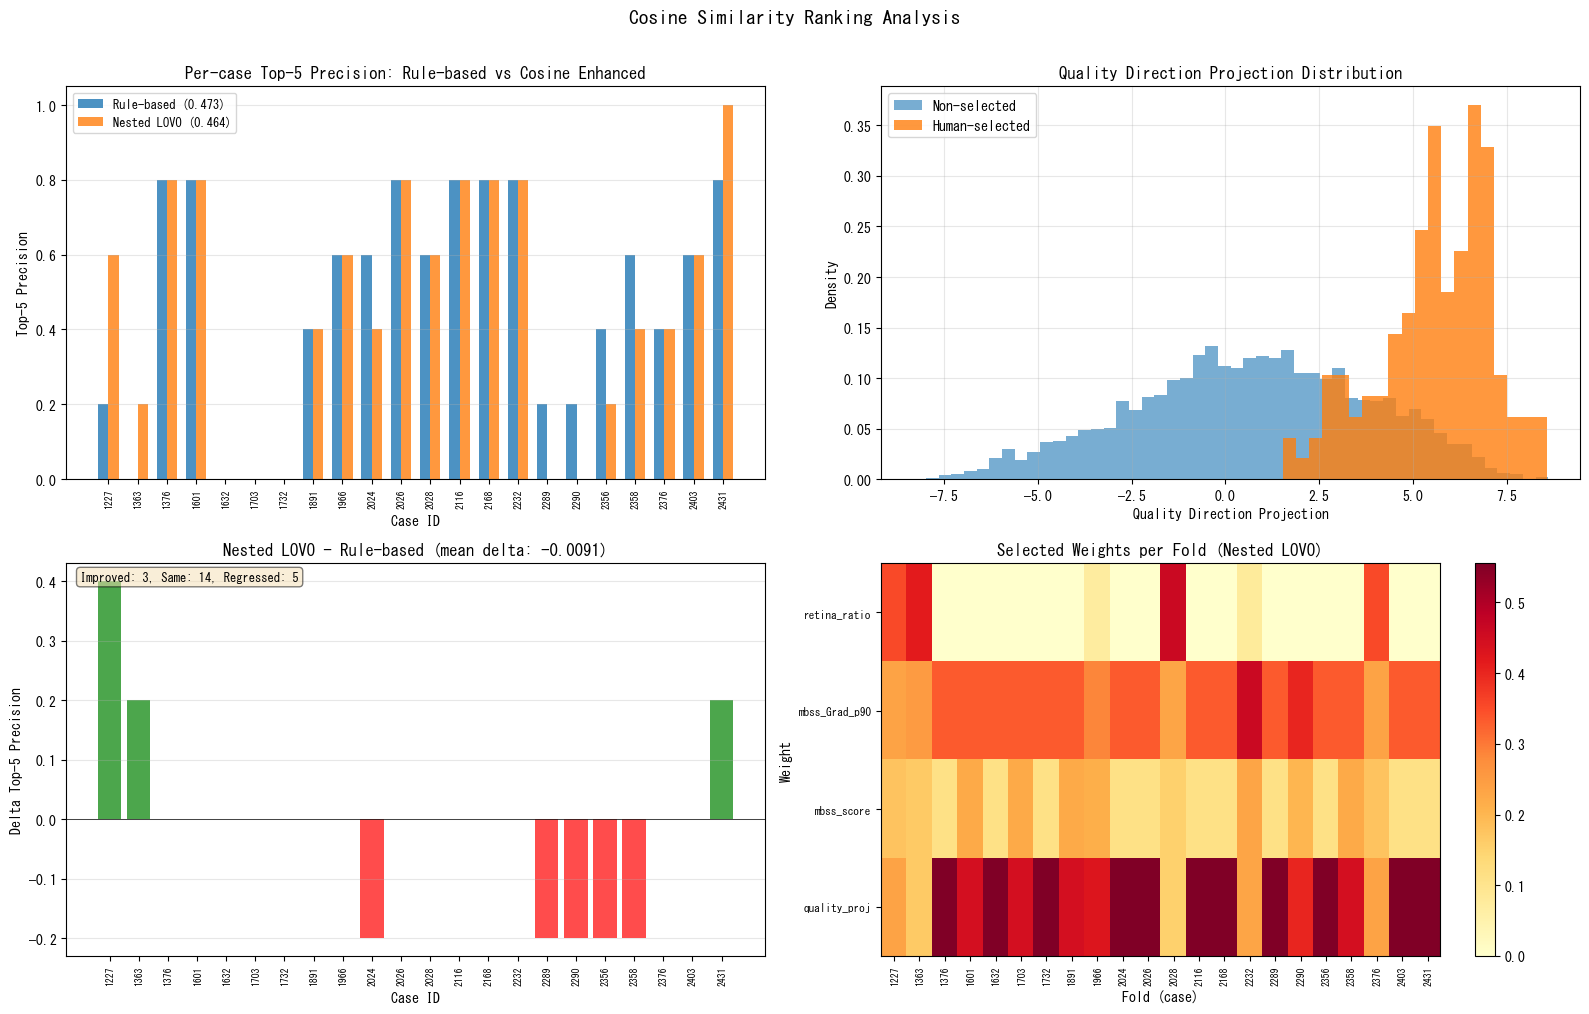

In [9]:
# ============================================================
# Cell 9: Per-case詳細比較 + 可視化
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot 1: Rule-based vs Nested LOVO per-case Top-5 Precision ---
ax = axes[0, 0]
x = np.arange(len(all_case_ids))
w = 0.35
ax.bar(x - w/2, rule_results['top5_precision'].values, w,
       label=f'Rule-based ({rule_results["top5_precision"].mean():.3f})', alpha=0.8)
ax.bar(x + w/2, nested_df['top5_precision'].values, w,
       label=f'Nested LOVO ({nested_df["top5_precision"].mean():.3f})', alpha=0.8)
ax.set_xlabel('Case ID')
ax.set_ylabel('Top-5 Precision')
ax.set_title('Per-case Top-5 Precision: Rule-based vs Cosine Enhanced')
ax.set_xticks(x)
ax.set_xticklabels(all_case_ids, rotation=90, fontsize=7)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 2: Quality Direction Projection histograms ---
ax = axes[0, 1]
# Compute quality direction on all training cases (illustrative)
qd_global = compute_quality_direction(all_case_ids, df, feat_dict)
all_projections = []
all_labels = []
for name in df['image_name']:
    if name in feat_dict:
        proj = feat_dict[name] @ qd_global
        all_projections.append(proj)
        all_labels.append(df.loc[df['image_name'] == name, 'is_human_top'].iloc[0])
all_projections = np.array(all_projections)
all_labels = np.array(all_labels)

ax.hist(all_projections[~all_labels], bins=50, alpha=0.6, label='Non-selected', density=True)
ax.hist(all_projections[all_labels], bins=20, alpha=0.8, label='Human-selected', density=True)
ax.set_xlabel('Quality Direction Projection')
ax.set_ylabel('Density')
ax.set_title('Quality Direction Projection Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Difference (nested - rule) per case ---
ax = axes[1, 0]
diff = nested_df['top5_precision'].values - rule_results['top5_precision'].values
colors = ['green' if d > 0 else ('red' if d < 0 else 'gray') for d in diff]
ax.bar(x, diff, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Case ID')
ax.set_ylabel('Delta Top-5 Precision')
ax.set_title(f'Nested LOVO - Rule-based (mean delta: {diff.mean():+.4f})')
ax.set_xticks(x)
ax.set_xticklabels(all_case_ids, rotation=90, fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

# Count improvements/regressions
n_improved = (diff > 0).sum()
n_regressed = (diff < 0).sum()
n_same = (diff == 0).sum()
ax.text(0.02, 0.98, f'Improved: {n_improved}, Same: {n_same}, Regressed: {n_regressed}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Plot 4: Weight selection heatmap ---
ax = axes[1, 1]
weight_matrix = weights_df[weight_names].values
im = ax.imshow(weight_matrix.T, aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Fold (case)')
ax.set_ylabel('Weight')
ax.set_title('Selected Weights per Fold (Nested LOVO)')
ax.set_xticks(range(len(all_case_ids)))
ax.set_xticklabels(all_case_ids, rotation=90, fontsize=7)
ax.set_yticks(range(len(weight_names)))
ax.set_yticklabels(weight_names, fontsize=8)
plt.colorbar(im, ax=ax)

plt.suptitle('Cosine Similarity Ranking Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Cell 10: 全手法比較テーブル
# ============================================================

print('=' * 80)
print('ALL METHODS COMPARISON')
print('=' * 80)
print()

comparison = {
    'Rule-based (3features, manual weights)': {
        'top5_precision': rule_results['top5_precision'].mean(),
        'video_match': rule_results['video_match'].mean(),
        'ndcg_at_5': rule_results['ndcg_at_5'].mean(),
        'mrr': rule_results['mrr'].mean(),
        'learning': 'None',
    },
    'Rule+QualProj (nested LOVO)': {
        'top5_precision': nested_df['top5_precision'].mean(),
        'video_match': nested_df['video_match'].mean(),
        'ndcg_at_5': nested_df['ndcg_at_5'].mean(),
        'mrr': nested_df['mrr'].mean(),
        'learning': 'Weight grid only',
    },
    'Rule+QualProj (oracle)': {
        'top5_precision': best_oracle_results['top5_precision'].mean(),
        'video_match': best_oracle_results['video_match'].mean(),
        'ndcg_at_5': best_oracle_results['ndcg_at_5'].mean(),
        'mrr': best_oracle_results['mrr'].mean(),
        'learning': 'Oracle (overfit)',
    },
    'Quality Direction Proj only': {
        'top5_precision': qd_results['top5_precision'].mean(),
        'video_match': qd_results['video_match'].mean(),
        'ndcg_at_5': qd_results['ndcg_at_5'].mean(),
        'mrr': qd_results['mrr'].mean(),
        'learning': 'None',
    },
    'Prototype cos_mean only': {
        'top5_precision': proto_mean_results['top5_precision'].mean(),
        'video_match': proto_mean_results['video_match'].mean(),
        'ndcg_at_5': proto_mean_results['ndcg_at_5'].mean(),
        'mrr': proto_mean_results['mrr'].mean(),
        'learning': 'None',
    },
    'Prototype cos_topk5 only': {
        'top5_precision': proto_topk_results['top5_precision'].mean(),
        'video_match': proto_topk_results['video_match'].mean(),
        'ndcg_at_5': proto_topk_results['ndcg_at_5'].mean(),
        'mrr': proto_topk_results['mrr'].mean(),
        'learning': 'None',
    },
    'Hybrid RETFound+MLP': {
        'top5_precision': 0.1000,
        'video_match': 0.3636,
        'ndcg_at_5': 0.1148,
        'mrr': 0.2439,
        'learning': 'MLP pairwise',
    },
    'Feature MLP (15dim)': {
        'top5_precision': 0.1910,
        'video_match': 0.5000,
        'ndcg_at_5': 0.2120,
        'mrr': 0.3740,
        'learning': 'MLP pairwise',
    },
}

comp_df = pd.DataFrame(comparison).T
comp_df.index.name = 'Method'

# Sort by top5_precision descending
comp_df = comp_df.sort_values('top5_precision', ascending=False)

print(comp_df.to_string(float_format='{:.4f}'.format))
print()

# Highlight key comparison
rule_p5 = rule_results['top5_precision'].mean()
nested_p5 = nested_df['top5_precision'].mean()
delta = nested_p5 - rule_p5
print(f'Key comparison:')
print(f'  Rule-based:                {rule_p5:.4f}')
print(f'  Rule+QualProj (nested):    {nested_p5:.4f} ({delta:+.4f})')
print(f'  Rule+QualProj (oracle):    {best_oracle_p5:.4f} ({best_oracle_p5 - rule_p5:+.4f})')

ALL METHODS COMPARISON

                                       top5_precision video_match ndcg_at_5    mrr          learning
Method                                                                                              
Rule+QualProj (oracle)                         0.5364      0.8636    0.5266 0.6709  Oracle (overfit)
Rule-based (3features, manual weights)         0.4727      0.8182    0.5137 0.7118              None
Rule+QualProj (nested LOVO)                    0.4636      0.7727    0.4768 0.6448  Weight grid only
Quality Direction Proj only                    0.4182      0.8636    0.4325 0.6285              None
Feature MLP (15dim)                            0.1910      0.5000    0.2120 0.3740      MLP pairwise
Prototype cos_topk5 only                       0.1909      0.5000    0.1972 0.3546              None
Prototype cos_mean only                        0.1182      0.3636    0.1092 0.2273              None
Hybrid RETFound+MLP                            0.1000      0.3636  

In [11]:
# ============================================================
# Cell 11: 結果保存 + 結論
# ============================================================

output_dir = config.output_dir
output_dir.mkdir(parents=True, exist_ok=True)

# Save all results
rule_results.to_csv(output_dir / 'rule_based_results.csv', index=False)
nested_df.to_csv(output_dir / 'nested_lovo_results.csv', index=False)
best_oracle_results.to_csv(output_dir / 'oracle_results.csv', index=False)
qd_results.to_csv(output_dir / 'quality_direction_only_results.csv', index=False)
proto_mean_results.to_csv(output_dir / 'prototype_cos_mean_results.csv', index=False)
proto_topk_results.to_csv(output_dir / 'prototype_cos_topk_results.csv', index=False)
comp_df.to_csv(output_dir / 'all_methods_comparison.csv')
weights_df.to_csv(output_dir / 'nested_lovo_selected_weights.csv', index=False)

# Save oracle weights
with open(output_dir / 'oracle_best_weights.txt', 'w') as f:
    for k, v in best_oracle_weights.items():
        f.write(f'{k}: {v:.6f}\n')

print(f'Results saved to {output_dir}/')
for p in sorted(output_dir.glob('*')):
    print(f'  {p.name}')

# --- Conclusion ---
print()
print('=' * 60)
print('CONCLUSION')
print('=' * 60)
print()
print(f'1. Rule-based baseline:           {rule_p5:.4f} Top-5 Precision')
print(f'2. Quality Direction Proj only:    {qd_results["top5_precision"].mean():.4f}')
print(f'3. Prototype cosine (mean) only:   {proto_mean_results["top5_precision"].mean():.4f}')
print(f'4. Rule+QualProj (nested LOVO):    {nested_df["top5_precision"].mean():.4f}')
print(f'5. Rule+QualProj (oracle):         {best_oracle_p5:.4f}')
print()

if nested_p5 > rule_p5:
    print(f'Quality Direction Projection IMPROVED rule-based by {delta:+.4f} (nested LOVO, unbiased)')
elif nested_p5 == rule_p5:
    print(f'Quality Direction Projection matched rule-based (no improvement)')
else:
    print(f'Quality Direction Projection did NOT improve rule-based ({delta:+.4f})')
    print(f'The oracle upper bound was {best_oracle_p5:.4f}, suggesting limited room for improvement')
    print(f'with this approach.')

print()
print('All MLP-based approaches remain far below rule-based (54.5%),')
print('confirming that learning on 22 cases does not generalize.')

Results saved to C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\cosine_ranking_outputs/
  all_methods_comparison.csv
  nested_lovo_results.csv
  nested_lovo_selected_weights.csv
  oracle_best_weights.txt
  oracle_results.csv
  prototype_cos_mean_results.csv
  prototype_cos_topk_results.csv
  quality_direction_only_results.csv
  rule_based_results.csv

CONCLUSION

1. Rule-based baseline:           0.4727 Top-5 Precision
2. Quality Direction Proj only:    0.4182
3. Prototype cosine (mean) only:   0.1182
4. Rule+QualProj (nested LOVO):    0.4636
5. Rule+QualProj (oracle):         0.5364

Quality Direction Projection did NOT improve rule-based (-0.0091)
The oracle upper bound was 0.5364, suggesting limited room for improvement
with this approach.

All MLP-based approaches remain far below rule-based (54.5%),
confirming that learning on 22 cases does not generalize.
